Desarrollado por Victoria Gutiérrez, G.Vinueza - UdeSA
#PCA


Importo librerías necesarias

In [1]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

import warnings
warnings.filterwarnings('ignore')

Obtengo un dataset

In [2]:
USArrests = sm.datasets.get_rdataset("USArrests", "datasets")
datos = USArrests.data
datos.head()

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6


Escalo los datos

In [3]:
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(datos)

Calculo matriz de covarianzas de mi dataset

In [4]:
datos_escalados.T

array([[ 1.25517927,  0.51301858,  0.07236067,  0.23470832,  0.28109336,
         0.02597562, -1.04088037, -0.43787481,  1.76541475,  2.22926518,
        -0.57702994, -1.20322802,  0.60578867, -0.13637203, -1.29599811,
        -0.41468229,  0.44344101,  1.76541475, -1.31919063,  0.81452136,
        -0.78576263,  1.00006153, -1.1800355 ,  1.9277624 ,  0.28109336,
        -0.41468229, -0.80895515,  1.02325405, -1.31919063, -0.08998698,
         0.83771388,  0.76813632,  1.20879423, -1.62069341, -0.11317951,
        -0.27552716, -0.66980002, -0.34510472, -1.01768785,  1.53348953,
        -0.92491776,  1.25517927,  1.13921666, -1.06407289, -1.29599811,
         0.16513075, -0.87853272, -0.48425985, -1.20322802, -0.22914211],
       [ 0.79078716,  1.11805959,  1.49381682,  0.23321191,  1.2756352 ,
         0.40290872, -0.73648418,  0.81502956,  1.99078607,  0.48775713,
        -1.51224105, -0.61527217,  0.94836277, -0.70012057, -1.39102904,
        -0.67587817, -0.74860538,  0.94836277, -1.

In [5]:
covarianzas = np.cov(datos_escalados.T)
covarianzas

array([[1.02040816, 0.81823807, 0.07099247, 0.57508044],
       [0.81823807, 1.02040816, 0.2641548 , 0.67881758],
       [0.07099247, 0.2641548 , 1.02040816, 0.41973595],
       [0.57508044, 0.67881758, 0.41973595, 1.02040816]])

Calculo autovalores y autovectores

In [6]:
autovalores, autovectores = np.linalg.eig(covarianzas)

In [7]:
autovalores

array([2.53085875, 1.00996444, 0.17696948, 0.36383998])

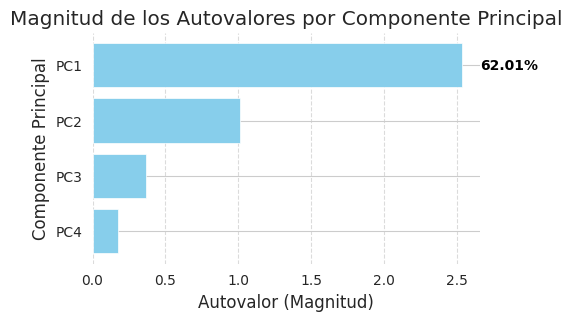

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

total_autovalores = np.sum(autovalores)
porcentaje_autovalores = (autovalores / total_autovalores) * 100

# Sort eigenvalues in descending order for better visualization
autovalores_sorted_idx = np.argsort(autovalores)[::-1]
autovalores_plot = autovalores[autovalores_sorted_idx]
porcentaje_autovalores_plot = porcentaje_autovalores[autovalores_sorted_idx]

plt.figure(figsize=(5, 3))
plt.barh(y=[f'PC{i+1}' for i in range(len(autovalores_plot))], width=autovalores_plot, color='skyblue')
plt.xlabel('Autovalor (Magnitud)')
plt.ylabel('Componente Principal')
plt.title('Magnitud de los Autovalores por Componente Principal')

# Annotate the first bar with its percentage
plt.text(autovalores_plot[0] * 1.05, 0, f'{porcentaje_autovalores_plot[0]:.2f}%', va='center', color='black', fontweight='bold')

plt.gca().invert_yaxis() # To have PC1 at the top
plt.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine(left=True, bottom=True)
plt.show()

In [9]:
autovectores

array([[ 0.53589947,  0.41818087,  0.6492278 , -0.34123273],
       [ 0.58318363,  0.1879856 , -0.74340748, -0.26814843],
       [ 0.27819087, -0.87280619,  0.13387773, -0.37801579],
       [ 0.54343209, -0.16731864,  0.08902432,  0.81777791]])

Varianza explicada acumulada

In [10]:
indices_ordenados = np.argsort(autovalores)[::-1]

autovalores_ordenados = autovalores[indices_ordenados]
autovectores_ordenados = autovectores[:, indices_ordenados]

var_exp = autovalores_ordenados / np.sum(autovalores_ordenados)
var_exp_acum = np.cumsum(var_exp)

resultados = pd.DataFrame({
    'Componente': [f'PC{i+1}' for i in range(len(var_exp))],
    'Varianza_Explicada': np.round(var_exp, 4),
    'Varianza_Acumulada': np.round(var_exp_acum, 4)
})

print(resultados)



  Componente  Varianza_Explicada  Varianza_Acumulada
0        PC1              0.6201              0.6201
1        PC2              0.2474              0.8675
2        PC3              0.0891              0.9566
3        PC4              0.0434              1.0000


Gráfico de la varianza explicada acumulada

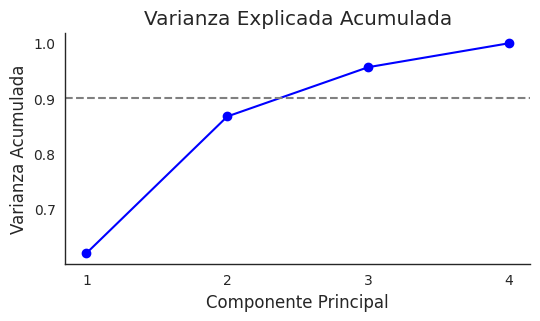

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("white")  # Sin fondo gris ni bordes

plt.figure(figsize=(6, 3))
plt.plot(range(1, 5), var_exp_acum[:4], marker='o', color='blue')
plt.axhline(y=0.9, color='gray', linestyle='--')
plt.xticks([1, 2, 3, 4])
plt.xlabel('Componente Principal')
plt.ylabel('Varianza Acumulada')
plt.title('Varianza Explicada Acumulada')
sns.despine()  # Quita bordes superior y derecho
plt.grid(False)  # Quita grilla
plt.show()




Haciendolo directamente con scikit learn

In [12]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(datos_escalados)


PCA()

In [13]:
var_exp_acum = np.cumsum(pca.explained_variance_ratio_)
var_exp_acum

array([0.62006039, 0.86750168, 0.95664248, 1.        ])

In [14]:
componentes_4 = pca.components_[:4]

componentes_df = pd.DataFrame(componentes_4,
                             columns=datos.columns,
                             index=[f'PC{i+1}' for i in range(4)])

print(componentes_df)


       Murder   Assault  UrbanPop      Rape
PC1  0.535899  0.583184  0.278191  0.543432
PC2 -0.418181 -0.187986  0.872806  0.167319
PC3 -0.341233 -0.268148 -0.378016  0.817778
PC4 -0.649228  0.743407 -0.133878 -0.089024


In [15]:
datos_pca = pca.transform(datos_escalados)
print("Shape of original scaled data:", datos_escalados.shape)
print("Shape of data transformed to PC space:", datos_pca.shape)
print("First 5 rows of transformed data (PC1, PC2, etc.):")
print(datos_pca[:5])

Shape of original scaled data: (50, 4)
Shape of data transformed to PC space: (50, 4)
First 5 rows of transformed data (PC1, PC2, etc.):
[[ 0.98556588 -1.13339238 -0.44426879 -0.15626714]
 [ 1.95013775 -1.07321326  2.04000333  0.43858344]
 [ 1.76316354  0.74595678  0.05478082  0.83465292]
 [-0.14142029 -1.11979678  0.11457369  0.1828109 ]
 [ 2.52398013  1.54293399  0.5985568   0.34199648]]


Aplicamos KMeans

In [24]:
#KMeans con dataset original
from sklearn.cluster import KMeans

k = 3
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans.fit(datos_escalados)

# Add cluster labels to the original data DataFrame
datos['Cluster'] = kmeans.labels_

print("Cluster centers (scaled features):")
print(kmeans.cluster_centers_)
print("\nFirst 5 rows of original data with cluster labels:")
print(datos.head())

Cluster centers (scaled features):
[[-0.70818765 -0.71433164 -0.10025286 -0.58360287]
 [ 1.42622412  0.88321132 -0.82279055  0.01946669]
 [ 0.70212683  1.04999438  0.72997363  1.28990383]]

First 5 rows of original data with cluster labels:
            Murder  Assault  UrbanPop  Rape  Cluster
rownames                                            
Alabama       13.2      236        58  21.2        1
Alaska        10.0      263        48  44.5        2
Arizona        8.1      294        80  31.0        2
Arkansas       8.8      190        50  19.5        1
California     9.0      276        91  40.6        2


In [25]:
cluster_means = datos.groupby('Cluster').mean()
print("Mean of each variable per cluster:")
print(cluster_means)

Mean of each variable per cluster:
            Murder     Assault   UrbanPop       Rape
Cluster                                             
0         4.734483  111.827586  64.103448  15.820690
1        13.937500  243.625000  53.750000  21.412500
2        10.815385  257.384615  76.000000  33.192308


KMeans con PCA

In [27]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA # Ensure PCA is imported

# Re-initialize and fit PCA (if not already in memory)
pca = PCA()
pca.fit(datos_escalados)

# Re-transform data to PCA space to ensure datos_pca is defined
datos_pca = pca.transform(datos_escalados)

k_pca = 3
kmeans_pca = KMeans(n_clusters=k_pca, random_state=42, n_init='auto')
kmeans_pca.fit(datos_pca)

# Create a DataFrame for PCA results with cluster labels
datos_pca_df = pd.DataFrame(datos_pca, columns=[f'PC{i+1}' for i in range(datos_pca.shape[1])], index=datos.index)
datos_pca_df['Cluster_PCA'] = kmeans_pca.labels_

print("Cluster centers (PCA components):")
print(kmeans_pca.cluster_centers_)
print("\nFirst 5 rows of PCA transformed data with cluster labels:")
print(datos_pca_df.head())

Cluster centers (PCA components):
[[-1.14114187  0.24528564 -0.00615666 -0.0058879 ]
 [ 1.06107315 -1.47733019 -0.39655882 -0.16093813]
 [ 1.89265608  0.36195062  0.25777029  0.11217339]]

First 5 rows of PCA transformed data with cluster labels:
                 PC1       PC2       PC3       PC4  Cluster_PCA
rownames                                                       
Alabama     0.985566 -1.133392 -0.444269 -0.156267            1
Alaska      1.950138 -1.073213  2.040003  0.438583            2
Arizona     1.763164  0.745957  0.054781  0.834653            2
Arkansas   -0.141420 -1.119797  0.114574  0.182811            1
California  2.523980  1.542934  0.598557  0.341996            2


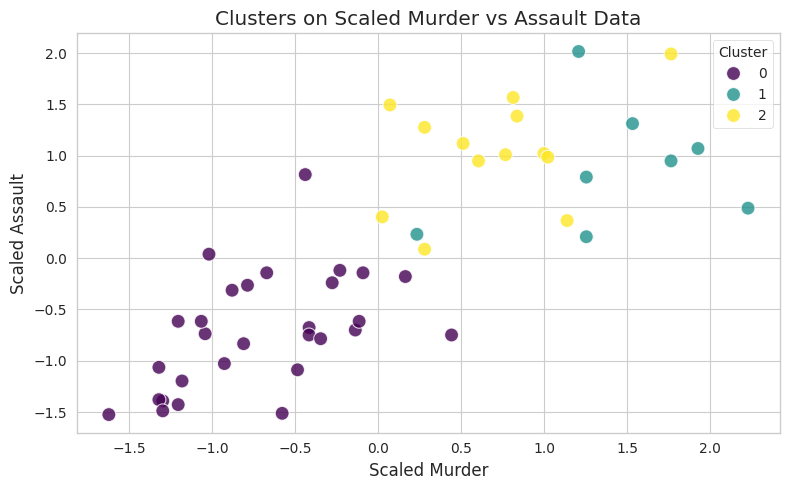

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# Create a DataFrame for scaled data with cluster labels for visualization
df_scaled_clustered = pd.DataFrame(datos_escalados, columns=datos.drop(columns='Cluster').columns, index=datos.index)
df_scaled_clustered['Cluster'] = kmeans.labels_

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='Murder',
    y='Assault',
    hue='Cluster',
    data=df_scaled_clustered,
    palette='viridis',
    s=100,
    alpha=0.8,
    legend='full'
)
plt.title('Clusters on Scaled Murder vs Assault Data')
plt.xlabel('Scaled Murder')
plt.ylabel('Scaled Assault')
plt.grid(True)
plt.tight_layout()
plt.show()

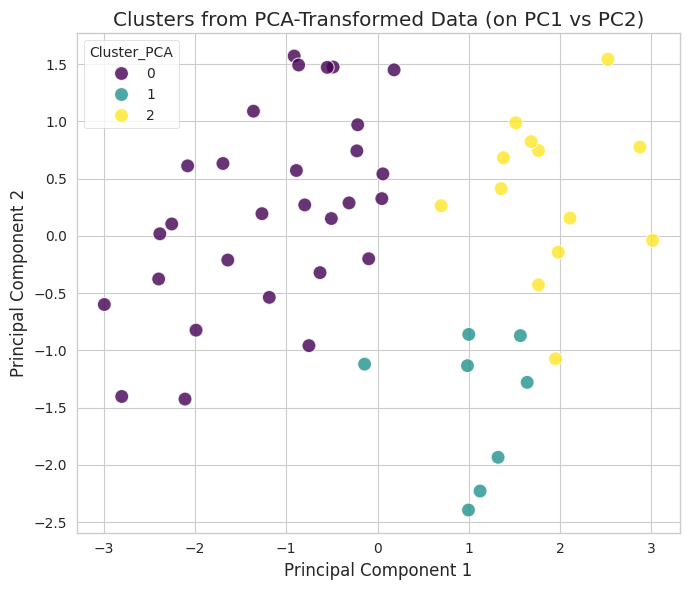

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

sns.set_style("whitegrid")

# Assuming datos_pca and kmeans_pca are already defined from previous steps
# (If not, these steps would need to be re-run first)

# Prepare data for plotting for PCA clusters on PCA space
df_pca_clusters_on_pca = pd.DataFrame(datos_pca[:, :2], columns=['PC1', 'PC2'], index=datos.index)
df_pca_clusters_on_pca['Cluster_PCA'] = kmeans_pca.labels_

plt.figure(figsize=(7, 6))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster_PCA', data=df_pca_clusters_on_pca,
    palette='viridis', s=100, alpha=0.8, legend='full'
)
plt.title('Clusters from PCA-Transformed Data (on PC1 vs PC2)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.tight_layout()
plt.show()

In [30]:
from sklearn.metrics import silhouette_score

silhouette_orig_scaled_data = silhouette_score(datos_escalados, kmeans.labels_)
silhouette_pca_data = silhouette_score(datos_pca, kmeans_pca.labels_)

In [31]:
print(f"Silhouette Score (Original Scaled Data): {silhouette_orig_scaled_data:.4f}")
print(f"Silhouette Score (PCA-transformed Data): {silhouette_pca_data:.4f}")

if silhouette_pca_data == silhouette_orig_scaled_data:
    print("Both clusterings have the same silhouette score.")
elif silhouette_pca_data > silhouette_orig_scaled_data:
    print("The clustering on PCA-transformed data has a higher silhouette score.")
else:
    print("The clustering on original scaled data has a higher silhouette score.")

Silhouette Score (Original Scaled Data): 0.3668
Silhouette Score (PCA-transformed Data): 0.3668
Both clusterings have the same silhouette score.


In [32]:
from sklearn.metrics import calinski_harabasz_score

# Calinski-Harabasz score for KMeans on original scaled data
ch_score_orig = calinski_harabasz_score(datos_escalados, kmeans.labels_)
print(f"Calinski-Harabasz Score (Original Scaled Data): {ch_score_orig:.4f}")

# Calinski-Harabasz score for KMeans on PCA-transformed data
ch_score_pca = calinski_harabasz_score(datos_pca, kmeans_pca.labels_)
print(f"Calinski-Harabasz Score (PCA-transformed Data): {ch_score_pca:.4f}")

print("\n--- Comparison ---")
if ch_score_pca > ch_score_orig:
    print("The clustering on the PCA-transformed data has a higher Calinski-Harabasz score.")
elif ch_score_orig > ch_score_pca:
    print("The clustering on the original scaled data has a higher Calinski-Harabasz score.")
else:
    print("Both clusterings have the same Calinski-Harabasz score.")

Calinski-Harabasz Score (Original Scaled Data): 32.9507
Calinski-Harabasz Score (PCA-transformed Data): 32.9507

--- Comparison ---
The clustering on the PCA-transformed data has a higher Calinski-Harabasz score.
